In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

##Часть А. Загрузка и подготовка данных (Базовый уровень)

In [ ]:
#часть А загрузка подготовка
img=Image.open('pic.jpg')
img_gray=img.convert('L')#преобразуем в серое
img_array=np.array(img_gray)#преобразуем в массив
print(img_array)

[[65 65 69 ...  4  4  4]
 [60 59 62 ...  4  4  4]
 [52 51 52 ...  4  4  4]
 ...
 [63 63 62 ...  1  1  1]
 [65 65 64 ...  1  1  1]
 [64 64 64 ...  1  1  1]]


считываем изображение, переводим его в градации серого и преобразовываем в массив

In [ ]:
M, N=img_array.shape#получаем размеры массива
print(M, N)

1632 1224


Получаем размеры полученного массива

In [ ]:
original_shape=(M, N)#сохраняем их вместе
original_flat=img_array.flatten()#преобразуем массив в вектор
print(original_flat)

[65 65 69 ...  1  1  1]


Сохраняем размеры вместе в одну переменную.
Далее преобразуем наш массив в одномерный вектор(для mse)

##Часть Б. Применение SVD и восстановление

In [ ]:
#часть Б. SVD
#делаем сингулярное разложение
U, s, Vt=np.linalg.svd(img_array, full_matrices=False)
#full_matrices=False важен для экономии памяти, иначе матрица U получится слишком большой.

#сжатие(апроксимация)
list_of_ranks=[1, 5, 10, 30, 100, min(M, N)]#список рангов для апроксимации
original_size=M*N#исходный размер

Делаем сингулярное разложение.
Любую матрицу $ A $ размером $ m \times n $ можно разложить на три матрицы:
$
A = U \cdot \Sigma \cdot V^T
$
Где:
- $ U $ — ортогональная матрица размера $ m \times m $ (левые сингулярные векторы).
- $ \Sigma $ — диагональная матрица размера $ m \times n $, на диагонали которой стоят сингулярные числа $ \sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $ V^T $ — ортогональная матрица размера $ n \times n $ (правые сингулярные векторы).

Используем специальную функцию, выполняющую сингулянрое разложение, разбирает матрицу на составные части.

Вводим список рангов для апроксимации.

Фиксируем исходный размер изображения.

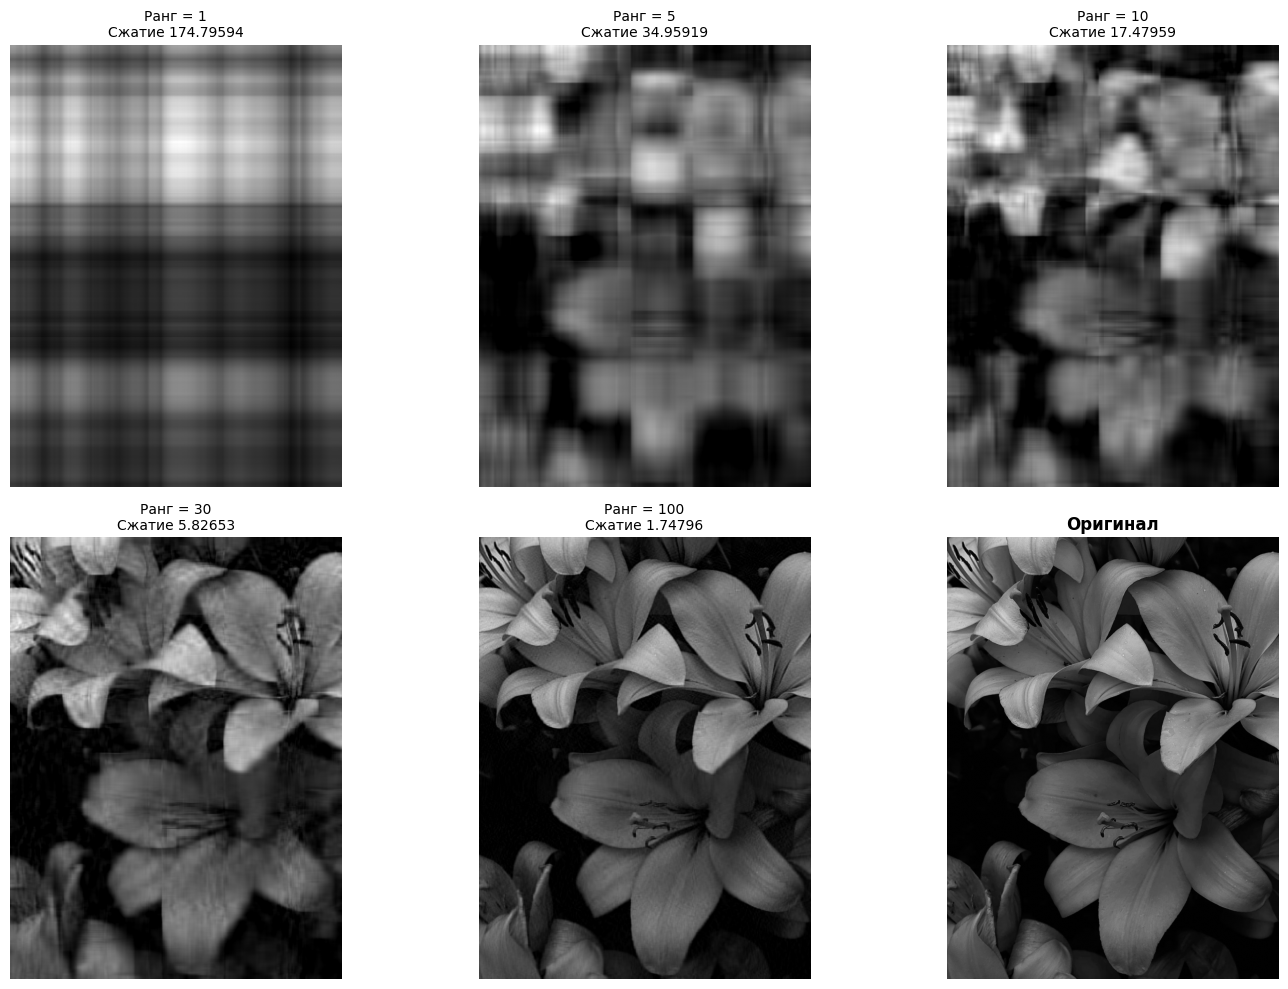

In [ ]:
#создаем ячейку для графиков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
approximations = []

for i, r in enumerate(list_of_ranks):#enumerate проходит по списку и одновременно дает номер итерации
  U_r = U[:, :r]#извлекаем первые r столбцов из U
  #[:, :r]-берем все строки (:), но только первые r столбцов (:r)
  S_r = np.diag(s[:r])#создаем диагональную матрицу из r сингулярных чисел
  Vt_r = Vt[:r, :]#извлекаем первые r строк
  reconstructed = U_r @ S_r @ Vt_r#восстановленная матрица
  # @-оператор матричного умножения

  #расчет сжатого предсталения
  #U_r: M*r чисел
  #S_r: r чисел
  #Vt_r: N*r чисел
  compressed_size=r*(M+N+1)*4#размер сжатого
  approximations.append(reconstructed)
  axes[i].imshow(np.clip(reconstructed, 0, 255), cmap="grey")
  #axes[i] - обращается к i-му графику (клеточке) на нашем холсте
  #.imshow() - показывает изображение в этой клеточке
  #np.clip(reconstructed, 0, 255) - обрезает значения, выходящие за диапазон [0, 255]
  #при восстановлении после SVD значения могут выйти за пределы [0, 255](черный и белый)
  #cmap="grey" - использует серую цветовую карту (для черно-белых изображений)
  axes[i].set_title(f"Ранг = {r}\nСжатие {round(original_size/compressed_size, 5)}", fontsize=10)
  #axes[i].set_title() - устанавливает заголовок для i-го графика
  #round(..., 5)-округление до 5 знаков послезапятой
  axes[i].axis('off')#отключаем отображение координат

#на последнем 6 графике покажем оригинал
#axes[5] - 6 элемент (индексация с 0)
axes[5].imshow(img_array, cmap='gray')
axes[5].set_title(f"Оригинал", fontsize=12, fontweight='bold')
axes[5].axis('off')

plt.tight_layout()#настраиваеся расстояние между графиками
plt.show()


Создаем холст, где будем располагать графики.

Создаем список для хранения восстановленных изображений.

Прописываем цикл, который будет восстанавливать изображение. Пробегаем по рангам из списка, для каждого извлекаются первые r компонентов SVD и проводим матричное умножение, получая восстановленную сжатую матрицу. находим размер сжатого.
добавляем восстановленную матрицу в список созданный.
Значения пикселей обрезаем до диапазона [0, 255]

Выводим наши графики

##делаем проверку

In [ ]:
# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


##проверка пройдена

##**ВЫВОДЫ**
В ходе выполнения домашнего задания мы провели сжатие изображения с помощью SVD/

Поняли, что это эффективный способ сжатия, который позволяет нам управлять качеством изображения